Análise de Modalidades Olímpicas

- Total de Modalidades Existentes por Edição
- Modalidades Existentes e Frequência

In [2]:
import pandas as pd
import os
import shutil

import json
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
from matplotlib.container import BarContainer
import seaborn as sns

## Abertura do Dataset

In [3]:
caminho_arquivo = "../../bronze/olympics_sports.parquet"
print(os.listdir("../../bronze"))

['olympics_athletes.json', 'olympics_athletes.parquet', 'olympics_medals.json', 'olympics_medals.parquet', 'olympics_sports.json', 'olympics_sports.parquet']


In [4]:
df_sports = pd.read_parquet(caminho_arquivo, engine="pyarrow")

df_sports.head()

,year,edition,edition_id,sport,event
0,1928,Winter Olympics,30,Skeleton,"Skeleton, Men"
1,1928,Winter Olympics,30,Skeleton,"Skeleton, Men"
2,1928,Winter Olympics,30,Skeleton,"Skeleton, Men"
3,1928,Winter Olympics,30,Skeleton,"Skeleton, Men"
4,1928,Winter Olympics,30,Skeleton,"Skeleton, Men"


## Tabela e Visualização

In [72]:
df_total = df_sports[df_sports['edition'].isin(['Summer Olympics', 'Winter Olympics'])]
df_events = (
    df_total.groupby('sport')['event']
    .nunique()
    .sort_values(ascending=False)
    .reset_index())

df_events.columns = ['sport', 'total_events']
df_events.head()

,sport,total_events
0,Athletics,202
1,Swimming,95
2,Shooting,92
3,Cycling Track,71
4,Artistic Gymnastics,53


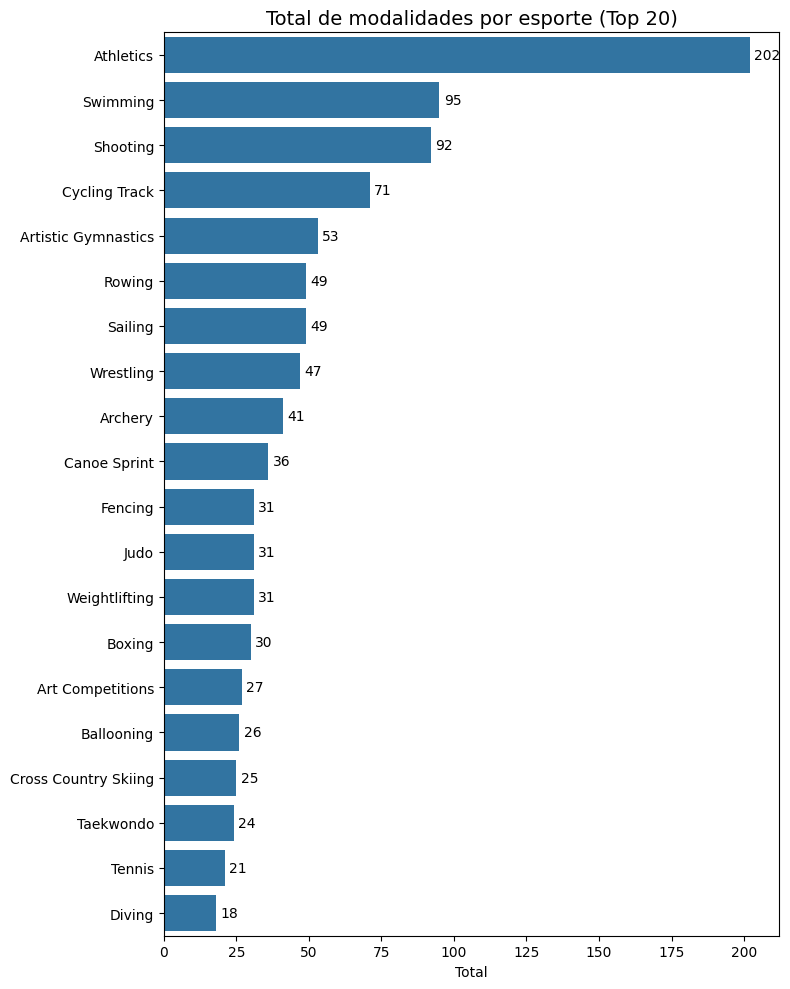

In [73]:
plt.figure(figsize=(8,10))

ax = sns.barplot(
    data=df_events.head(20), 
    x='total_events',
    y='sport',
    orient='h'
)

ax.bar_label(ax.containers[0], color='black', padding=3)

plt.title("Total de modalidades por esporte (Top 20)", fontsize=14)
plt.xlabel("Total")
plt.ylabel("")

plt.tight_layout()
plt.show()

## Salvando Arquivos

In [79]:
df_events.reset_index().to_csv("sport_events_summary.csv", index=False)


In [ ]:
metadado = {
    "nome": "Total de Modalidades por Esporte",
    "fonte": "olympic_sports.parquet",
    "descricao": "Contagem de modalidades existentes por esporte",
    "campos": [
        "index",
        "sport",
        "total_events",
    ],
    "data_coleta": datetime.now().strftime("%d-%m-%Y"),
    "observacoes": "A contagem é referente as modalidades dos Jogos Olímpicos de Verão e Inverno"
}

In [77]:
caminho_metadata = "sport_events_summary.json"

with open(caminho_metadata, "w", encoding='utf-8') as f:
    json.dump(metadado, f, ensure_ascii=False, indent=4)